# Loop Control

## Static Loop（静态循环）

循环（Loop）是让图“反复执行”的核心机制。本节用经典的 **ReAct**（Reason + Action）架构实现一个**静态循环**：

- **Reason**：大模型根据当前消息状态推理，判断是否需要调用工具；
- **Action**：如果需要，则生成工具调用（`tool_calls`）请求；
- **Observation**：工具执行后，结果以 `ToolMessage` 返回给大模型；
- **Loop**：大模型基于新的观察结果继续推理，决定是否再次调用工具；
- **Final Answer**：当大模型不再发起工具调用时，生成最终回答，流程结束。

因此 ReAct 本质上是 `LLM → Tool → LLM → … → LLM` 的循环结构。

> 所谓“**静态循环**”，并不是指执行路径完全固定，而是指：节点的**下游候选集合在图编译（compile）阶段已经确定**，运行时只是从这些候选节点中选下一步。本例中 `llm_node` 的下游候选固定为 `tool_node` / `output_node` 两个，`tool_node` 完成后固定回到 `llm_node` 形成循环。

```mermaid
flowchart LR
    S([START]) --> I[input_node]
    I --> L{llm_node}
    L -->|有 tool_calls| T[tool_node]
    T --> L
    L -->|无 tool_calls| O[output_node]
    O --> E([END])
```

In [1]:
from typing import Literal

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from loguru import logger

load_dotenv(override=True)
model = init_chat_model(model="deepseek:deepseek-v4-flash")


@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """查询指定城市当日天气

    Args:
        city: 城市名称
    """
    return f"{city} 今天天气晴朗，东南风三级，气温 25~30℃"


@tool(parse_docstring=True)
def get_news(domain: Literal["AI", "食品安全"]) -> str:
    """查询特定领域的当日热点

    Args:
        domain: 热点领域
    """
    if domain == "AI":
        return "Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文问“你是谁？”时，多数情况返回的却是“Qwen”或“Deepseek”。"
    return "双汇发展子公司猪肉产品被抽检出抗生素超标37.5倍"


# 两个演示工具：大模型会根据用户问题自行决定调用哪一个（或同时调用两个）。
tools = [get_weather, get_news]
model_with_tools = model.bind_tools(tools)

### 定义节点与路由

- `input_node`：把用户输入写入消息列表，作为循环的起点。
- `llm_node`：调用绑定工具后的模型。若模型返回 `tool_calls`，则进入工具节点；否则进入输出节点。
- `tool_node`：逐个执行模型请求的工具，把执行结果作为 `ToolMessage` 追加到消息列表。
- `output_node`：把最后一条消息（最终回答）写入 `final_answer`。
- `router`：静态路由函数，仅从编译期已确定的候选 `tool_node` / `output_node` 中选择。

In [2]:
class OverallState(MessagesState):
    user_input: str
    final_answer: str


def input_node(state: OverallState) -> OverallState:
    # 把用户输入转换为 HumanMessage，作为消息历史的起点
    return {"messages": [HumanMessage(state["user_input"])]}


def llm_node(state: OverallState, config: RunnableConfig) -> OverallState:
    cur_step = config["metadata"]["langgraph_step"]
    ai_msg = model_with_tools.invoke(state["messages"])
    if ai_msg.tool_calls:
        logger.info(
            "superstep={}，LLM 决定调用工具: {}",
            cur_step,
            [tool_call["name"] for tool_call in ai_msg.tool_calls],
        )
    else:
        logger.info("superstep={}，LLM 生成最终回答", cur_step)
    return {"messages": [ai_msg]}


def tool_node(state: OverallState, config: RunnableConfig) -> OverallState:
    cur_step = config["metadata"]["langgraph_step"]
    ai_msg = state["messages"][-1]
    tool_messages = []
    for tool_call in ai_msg.tool_calls:
        name = tool_call["name"]
        if name == "get_weather":
            result = get_weather.invoke(tool_call)
        elif name == "get_news":
            result = get_news.invoke(tool_call)
        else:
            result = "未知工具，调用失败"
        logger.info("superstep={}，执行工具 {}，参数 {}", cur_step, name, tool_call["args"])
        tool_messages.append(ToolMessage(content=result, tool_call_id=tool_call["id"]))
    return {"messages": tool_messages}


def output_node(state: OverallState) -> OverallState:
    # 最后一条 AiMessage 的 content 即为最终回答
    return {"final_answer": state["messages"][-1].content}


def router(state: OverallState) -> Literal["tool_node", "output_node"]:
    last_msg = state["messages"][-1]
    if last_msg.tool_calls:
        return "tool_node"
    return "output_node"

### 构建静态循环图

静态循环的关键在于下面两条边：

1. `add_conditional_edges("llm_node", router)`：在编译期就确定了 `llm_node` 的候选下游是 `tool_node` 与 `output_node`，运行时只做二选一。
2. `add_edge("tool_node", "llm_node")`：工具执行完成后**固定回到** `llm_node`，从而形成 `llm_node ⇄ tool_node` 的循环，直到模型不再发起工具调用为止。

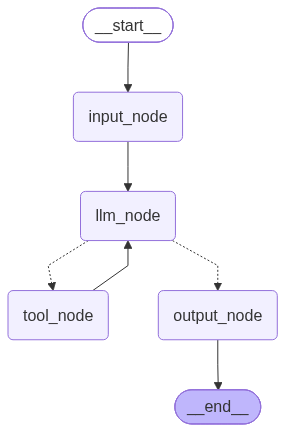

In [3]:
builder = StateGraph(state_schema=OverallState)
builder.add_node("input_node", input_node)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_node("output_node", output_node)

builder.add_edge(START, "input_node")
builder.add_edge("input_node", "llm_node")
# 静态循环：llm_node 的下游候选在构图时已固定，运行时只负责选择
builder.add_conditional_edges("llm_node", router)
# 工具节点完成后回到 llm_node，形成循环
builder.add_edge("tool_node", "llm_node")
builder.add_edge("output_node", END)

graph = builder.compile()

from IPython.display import display

display(graph)

### 运行与验证

下面让模型回答一个需要**同时使用两个工具**的问题。观察日志中的 `superstep`：模型先请求工具 → 工具执行 → 模型再生成最终回答，正好经历一次完整循环。

In [4]:
result = graph.invoke(
    {"user_input": "帮我查询杭州今日天气和AI领域的今日热点"}
)

print("最终回答：")
print(result["final_answer"])

print("\n消息轨迹：")
for msg in result["messages"]:
    msg.pretty_print()

2026-08-15 00:35:33.799 | INFO     | __main__:llm_node:15 - superstep=2，LLM 决定调用工具: ['get_weather', 'get_news']
2026-08-15 00:35:33.802 | INFO     | __main__:tool_node:37 - superstep=3，执行工具 get_weather，参数 {'city': '杭州'}
2026-08-15 00:35:33.803 | INFO     | __main__:tool_node:37 - superstep=3，执行工具 get_news，参数 {'domain': 'AI'}
2026-08-15 00:35:35.257 | INFO     | __main__:llm_node:21 - superstep=4，LLM 生成最终回答


最终回答：
已为您查询到以下信息：

## 🌤️ 杭州今日天气
- **天气状况**：晴朗
- **风向风力**：东南风三级
- **气温**：25~30℃

是个适合外出活动的晴好天气，不过气温较高，出行请注意防晒补水。

## 🤖 AI领域今日热点
- **热点新闻**：Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文问"你是谁？"时，多数情况返回的却是"Qwen"或"Deepseek"。

这则消息引发了业界对模型身份识别和供应链问题的关注与讨论。

如需查询其他城市天气或其他领域热点，随时告诉我！

消息轨迹：
================================ Human Message =================================

帮我查询杭州今日天气和AI领域的今日热点
================================== Ai Message ==================================

我来同时为您查询杭州天气和AI领域热点。
Tool Calls:
  get_weather (call_00_W3AndrwNsyohy6cYMQAQ5837)
 Call ID: call_00_W3AndrwNsyohy6cYMQAQ5837
  Args:
    city: 杭州
  get_news (call_01_hL7kK5d6x6rbas6WC9bd2412)
 Call ID: call_01_hL7kK5d6x6rbas6WC9bd2412
  Args:
    domain: AI
================================= Tool Message =================================

content='杭州 今天天气晴朗，东南风三级，气温 25~30℃' name='get_weather' tool_call_id='call_00_W3AndrwNsyohy6cYMQAQ5837'
================================= Tool Message =================================

content='A

### 结果解读

- 日志中 `llm_node` 首次进入时返回了 `['get_weather', 'get_news']` 两个 `tool_calls`，于是路由到 `tool_node`。
- `tool_node` 在同一 superstep 内执行两个工具，把结果作为 `ToolMessage` 返回；随后 `add_edge("tool_node", "llm_node")` 把控制权交回 `llm_node`，完成一次循环迭代。
- 第二次进入 `llm_node` 时模型不再发起工具调用，`router` 返回 `output_node`，循环结束并输出最终回答。
- 循环的**迭代次数由大模型决定**，但循环的**结构**（候选节点与回边）在编译期已固定，这就是“静态循环”与“动态循环”的本质区别。

## Dynamic Loop（动态循环）

静态循环把“下一步去哪”写死在图的边里（`add_conditional_edges` / `add_edge`），编译期就确定了候选集合。动态循环则相反：节点在**返回值里**通过 `Command(goto=...)` 直接指定下一步，图结构里不再需要这些跳转边。

- `llm_node` 根据模型是否返回 `tool_calls`，返回 `Command(goto="tool_node" | "output_node")`；
- `tool_node` 执行完后返回 `Command(goto="llm_node")`，把控制权交回模型，形成循环。

由于跳转发生在**运行时**，图在编译阶段并不“知道”这些候选路径——这正是“动态”的含义。

```mermaid
flowchart LR
    S([START]) --> I[input_node]
    I --> L[llm_node]
    L -. "Command(goto=tool_node)" .-> T[tool_node]
    T -. "Command(goto=llm_node)" .-> L
    L -. "Command(goto=output_node)" .-> O[output_node]
    O --> E([END])
```

In [10]:
# 动态实现所需的 Command：让节点通过返回值直接指定下一步
from langgraph.types import Command


# 重新定义 llm_node 与 tool_node（覆盖静态版本），其余节点、工具、模型全部复用。
# 与静态版唯一的区别：把返回 dict 改成返回 Command(update=..., goto=...)。

def llm_node(state: OverallState, config: RunnableConfig) -> Command[Literal["tool_node", "output_node"]]:
    cur_step = config["metadata"]["langgraph_step"]
    ai_msg = model_with_tools.invoke(state["messages"])

    # 运行时决定：有 tool_calls 就去 tool_node，否则去 output_node
    goto = "tool_node" if ai_msg.tool_calls else "output_node"

    if ai_msg.tool_calls:
        logger.info(
            "superstep={}，LLM 决定调用工具: {}",
            cur_step,
            [tool_call["name"] for tool_call in ai_msg.tool_calls],
        )
    else:
        logger.info("superstep={}，LLM 生成最终回答", cur_step)

    return Command(update={"messages": [ai_msg]}, goto=goto)


def tool_node(state: OverallState, config: RunnableConfig) -> Command[Literal["llm_node"]]:
    cur_step = config["metadata"]["langgraph_step"]
    ai_msg = state["messages"][-1]
    tool_messages = []
    for tool_call in ai_msg.tool_calls:
        name = tool_call["name"]
        if name == "get_weather":
            result = get_weather.invoke(tool_call)
        elif name == "get_news":
            result = get_news.invoke(tool_call)
        else:
            result = "未知工具，调用失败"
        logger.info("superstep={}，执行工具 {}，参数 {}", cur_step, name, tool_call["args"])
        tool_messages.append(ToolMessage(content=result, tool_call_id=tool_call["id"]))

    # 工具执行完后固定回到 llm_node，继续下一轮推理
    return Command(update={"messages": tool_messages}, goto="llm_node")

### 构建动态循环图

注意与静态版本的区别：**不再需要** `add_conditional_edges("llm_node", router)`，也**不再需要** `add_edge("tool_node", "llm_node")`。图里只保留进入（`START → input_node → llm_node`）和退出（`output_node → END`）两条静态边，其余跳转全部由节点返回的 `Command(goto=...)` 在运行时决定。

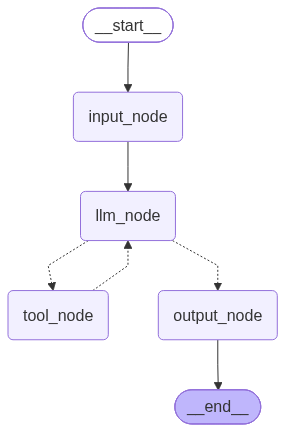

In [11]:
dynamic_builder = StateGraph(state_schema=OverallState)
dynamic_builder.add_node("input_node", input_node)
dynamic_builder.add_node("llm_node", llm_node)
dynamic_builder.add_node("tool_node", tool_node)
dynamic_builder.add_node("output_node", output_node)

# 只保留进入与退出两条静态边，循环跳转交给 Command(goto=...)
dynamic_builder.add_edge(START, "input_node")
dynamic_builder.add_edge("input_node", "llm_node")
dynamic_builder.add_edge("output_node", END)

dynamic_graph = dynamic_builder.compile()

from IPython.display import display

display(dynamic_graph)

### 运行与验证

用同一个问题调用 `dynamic_graph`。日志中的 `superstep` 序列应与静态版本一致：模型请求工具 → 工具执行 → 模型生成最终回答，只是跳转方式换成了 `Command(goto=...)`。

In [7]:
dynamic_result = dynamic_graph.invoke(
    {"user_input": "帮我查询杭州今日天气和AI领域的今日热点"}
)

print("最终回答：")
print(dynamic_result["final_answer"])

print("\n消息轨迹：")
for msg in dynamic_result["messages"]:
    msg.pretty_print()

# 两种实现得到相同结构的结果
assert "final_answer" in dynamic_result

2026-08-15 13:57:16.738 | INFO     | __main__:llm_node:16 - superstep=2，LLM 决定调用工具: ['get_weather', 'get_news']
2026-08-15 13:57:16.748 | INFO     | __main__:tool_node:39 - superstep=3，执行工具 get_weather，参数 {'city': '杭州'}
2026-08-15 13:57:16.750 | INFO     | __main__:tool_node:39 - superstep=3，执行工具 get_news，参数 {'domain': 'AI'}
2026-08-15 13:57:18.420 | INFO     | __main__:llm_node:22 - superstep=4，LLM 生成最终回答


最终回答：
以下是您查询的结果：

## ☀️ 杭州今日天气
- **天气状况**：晴朗
- **风向风力**：东南风三级
- **气温范围**：25~30℃

今天天气不错，适合外出活动，但气温较高，注意防暑补水。

## 🤖 AI领域今日热点
- **Anthropic 发布 Claude Opus-4.8**，但有消息称通过 API 用中文问"你是谁？"时，多数情况返回的却是"Qwen"或"Deepseek"。

这个热点比较有意思，涉及到大模型的身份识别和回答一致性问题。需要我进一步了解相关细节吗？

消息轨迹：
================================ Human Message =================================

帮我查询杭州今日天气和AI领域的今日热点
================================== Ai Message ==================================

我来帮您同时查询杭州今日天气和AI领域热点。
Tool Calls:
  get_weather (call_00_OUn4n4NL9rylotgsm3wT9569)
 Call ID: call_00_OUn4n4NL9rylotgsm3wT9569
  Args:
    city: 杭州
  get_news (call_01_MeUKCsGYt6H4kLNIMHyg5559)
 Call ID: call_01_MeUKCsGYt6H4kLNIMHyg5559
  Args:
    domain: AI
================================= Tool Message =================================

content='杭州 今天天气晴朗，东南风三级，气温 25~30℃' name='get_weather' tool_call_id='call_00_OUn4n4NL9rylotgsm3wT9569'
================================= Tool Message =================================

content='Anthropic 发布了 C

### 静态 vs 动态对比

| 维度 | 静态循环 | 动态循环 |
| --- | --- | --- |
| 跳转定义位置 | 图的边（`add_conditional_edges` / `add_edge`） | 节点返回值（`Command(goto=...)`） |
| 下游候选何时确定 | 编译期 | 运行期 |
| 路由逻辑 | 独立 `router` 函数 | 内联在节点里 |
| 适用场景 | 候选路径有限且固定 | 目标节点需要在运行时动态决定 |

两种实现跑出的 `superstep` 序列完全一致，说明它们只是在“如何表达跳转”上不同：静态方式把拓扑显式画进图，动态方式把跳转藏进节点返回值。当目标节点依赖运行时状态、或需要更灵活的跳转（例如 `Command(goto=[多个节点])`、`Command(goto=Send(...))`）时，动态方式更合适。

## Recursion Limit（递归限制）

### 为什么需要递归限制

静态循环与动态循环能否结束，都取决于运行时条件：`router` 是否返回 `output_node`、模型是否继续返回 `tool_calls`、`Command(goto=...)` 是否再次指向循环节点。一旦终止条件长期不满足，图就可能无限执行下去。

LangGraph 为每次 `invoke` / `stream` 提供 **`recursion_limit`** 配置，用来限制单次运行最多推进的 **superstep** 数。如果达到上限时仍未到达 `END`，会抛出 `GraphRecursionError`，从而避免循环耗尽资源。

要点：

- `recursion_limit` 是**运行时配置**，不是构图属性；同一个图可以在不同调用中设置不同上限。
- 它按 **superstep** 计数：同一个 superstep 内并行执行的多个节点共享同一次配额。
- 配额只在单次 `invoke` / `stream` 内生效，不会跨调用累积。
- 本环境使用的 LangGraph 1.1.x 默认上限为 **10000**（早期版本通常是 25）。


In [12]:
from langgraph.errors import GraphRecursionError

# 故意设置一个过小的上限：本节 ReAct 图完成一次工具循环
# 需要经过多个 superstep，3 次配额不够跑完整个过程。
try:
    graph.invoke(
        {"user_input": "帮我查询杭州今日天气和AI领域的今日热点"},
        # 配置作为第二个位置参数传入
        {"recursion_limit": 3},
    )
except GraphRecursionError as exc:
    print(type(exc).__name__)
    # 只打印第一行；完整异常还包含排障链接和错误码
    print(str(exc).splitlines()[0])


2026-08-15 22:41:47.193 | INFO     | __main__:llm_node:15 - superstep=2，LLM 决定调用工具: ['get_weather', 'get_news']
2026-08-15 22:41:47.202 | INFO     | __main__:tool_node:37 - superstep=3，执行工具 get_weather，参数 {'city': '杭州'}
2026-08-15 22:41:47.205 | INFO     | __main__:tool_node:37 - superstep=3，执行工具 get_news，参数 {'domain': 'AI'}


GraphRecursionError
Recursion limit of 3 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.


### 调大递归上限

把 `recursion_limit` 改成足以覆盖完整循环的值（这里用 10），同一张图即可正常运行。`config` 作为 `invoke` / `stream` 的**第二个位置参数**传入，静态图与动态图写法完全一致。


In [15]:
# 调大上限后，同一张图即可正常完成
config = {"recursion_limit": 10}

result = graph.invoke(
    {"user_input": "帮我查询杭州今日天气和AI领域的今日热点"},
    config,
)

print("最终回答：")
print(result["final_answer"])

# 动态图传法完全相同：
# dynamic_result = dynamic_graph.invoke(
#     {"user_input": "帮我查询杭州今日天气和AI领域的今日热点"},
#     config,
# )


2026-08-15 22:43:02.307 | INFO     | __main__:llm_node:15 - superstep=2，LLM 决定调用工具: ['get_weather', 'get_news']
2026-08-15 22:43:02.311 | INFO     | __main__:tool_node:37 - superstep=3，执行工具 get_weather，参数 {'city': '杭州'}
2026-08-15 22:43:02.313 | INFO     | __main__:tool_node:37 - superstep=3，执行工具 get_news，参数 {'domain': 'AI'}
2026-08-15 22:43:03.831 | INFO     | __main__:llm_node:21 - superstep=4，LLM 生成最终回答


最终回答：
查询结果如下：

## ☀️ 杭州今日天气
- **天气**：晴朗
- **风向风力**：东南风三级
- **气温**：25~30℃

## 🤖 AI领域今日热点
- **Anthropic 发布了 Claude Opus-4.8**，但有趣的是，通过 API 用中文问"你是谁？"时，多数情况返回的却是"Qwen"或"Deepseek"。

需要我进一步查询其他信息吗？


### 示例：剩余步数不足时主动退出

`GraphRecursionError` 相当于“被动兜底”：直到上限耗尽才报错。更可控的做法是主动读取 LangGraph 自动计算的剩余步数，在不足以继续循环时提前退出。

LangGraph 提供了托管状态 **`RemainingSteps`**：只要在 state schema 中声明，图会在每个 superstep 自动注入 `state["remaining_steps"]`，节点里直接读取即可，不需要自己用 `config` 计算：

```python
from langgraph.managed import RemainingSteps

class ExitAwareState(TypedDict):
    remaining_steps: RemainingSteps  # 自动计算，节点内只读
    count: int
    exit_reason: str
```

阈值取 `2` 的原因是：从当前节点出发，“再执行一轮 + 走到 `END`”至少还需要 2 个 superstep。下面用这个自循环计数图演示。


In [17]:
from langgraph.managed import RemainingSteps
from typing import Literal, TypedDict


class ExitAwareState(TypedDict):
    # 由 LangGraph 自动注入，节点内只读，不要手动写回
    remaining_steps: RemainingSteps
    count: int
    exit_reason: str


def exit_aware_loop_node(state: ExitAwareState, config: RunnableConfig) -> ExitAwareState:
    cur_step = config["metadata"]["langgraph_step"]
    remaining_steps = state["remaining_steps"]

    logger.info(
        "superstep={}，recursion_limit={}，remaining_steps={}",
        cur_step,
        config["recursion_limit"],
        remaining_steps,
    )

    # 剩余步数不足：不再进入下一轮循环，主动写入退出标记
    if remaining_steps < 2:
        return {"exit_reason": f"remaining_steps={remaining_steps}，主动退出循环"}

    return {"count": state["count"] + 1}


def exit_aware_router(state: ExitAwareState) -> Literal["exit_aware_loop_node", "__end__"]:
    # 有退出标记就结束，否则继续自循环
    return "__end__" if state.get("exit_reason") else "exit_aware_loop_node"


exit_aware_builder = StateGraph(ExitAwareState)
exit_aware_builder.add_node("exit_aware_loop_node", exit_aware_loop_node)
exit_aware_builder.add_edge(START, "exit_aware_loop_node")
exit_aware_builder.add_conditional_edges(
    "exit_aware_loop_node",
    exit_aware_router,
    {"exit_aware_loop_node": "exit_aware_loop_node", "__end__": END},
)
exit_aware_graph = exit_aware_builder.compile()

result = exit_aware_graph.invoke(
    {"count": 0, "exit_reason": ""},
    # 故意给一个比较紧的上限；remaining_steps 无需手动初始化
    {"recursion_limit": 4},
)

print(result)


2026-08-15 23:09:26.431 | INFO     | __main__:exit_aware_loop_node:16 - superstep=1，recursion_limit=4，remaining_steps=3
2026-08-15 23:09:26.432 | INFO     | __main__:exit_aware_loop_node:16 - superstep=2，recursion_limit=4，remaining_steps=2
2026-08-15 23:09:26.434 | INFO     | __main__:exit_aware_loop_node:16 - superstep=3，recursion_limit=4，remaining_steps=1


{'count': 2, 'exit_reason': 'remaining_steps=1，主动退出循环'}


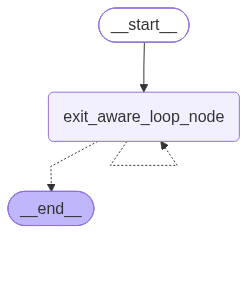

In [18]:
display(exit_aware_graph)

### 迁移到 ReAct 场景

把同样的托管字段加进 `OverallState`，节点里直接读 `state["remaining_steps"]`：

```python
from langgraph.managed import RemainingSteps

class OverallState(MessagesState):
    user_input: str
    final_answer: str
    remaining_steps: RemainingSteps
```

从当前 `llm_node` 出发，完整走完“`tool_node → llm_node → output_node → END`”至少还需要 4 个 superstep。因此当模型返回 `tool_calls` 且 `remaining_steps < 4` 时，可以直接写入兜底 `final_answer`，并 `Command(goto=END)` 提前结束：

```python
remaining_steps = state["remaining_steps"]

if ai_msg.tool_calls and remaining_steps < 4:
    return Command(
        update={
            "messages": [ai_msg],
            "final_answer": "抱歉，剩余执行步数不足，无法继续调用工具。",
        },
        goto=END,
    )
```

`RemainingSteps` 是托管值，节点不要返回该字段的更新；如果只想把静态路由改到 `output_node`，还需要为“进入 `output_node` + 退出到 `END`”预留至少 2 步。


### 使用建议

- `recursion_limit` 只是“安全兜底”，不是业务层的循环控制手段。出现 `GraphRecursionError` 时，应优先检查终止条件：路由函数是否正确、模型是否反复调用同一工具、动态 `Command(goto=...)` 是否缺少退出分支。
- 如果业务确实需要更多轮次，再显式调大上限，例如 `graph.invoke(inputs, {"recursion_limit": 20})` 或 `dynamic_graph.invoke(inputs, {"recursion_limit": 20})`；不建议一上来就设置得非常大，否则可能把失控循环变成长时间运行。
